In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Importing the data
df = pd.read_csv("heights_and_scores.csv")
df.head()

,person_id,height_cm,exam_score
0,H0000,184.0,68.9
1,H0001,158.1,77.9
2,H0002,174.0,69.8
3,H0003,165.8,82.5
4,H0004,165.2,73.0


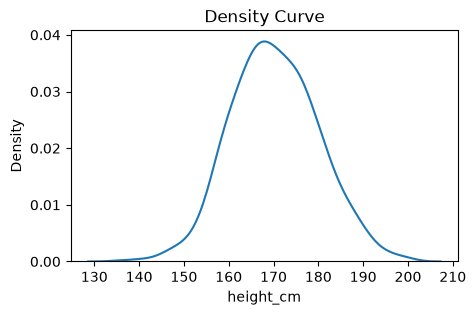

In [3]:
# KDE (Kernel Density Estimation) Plot
plt.figure(figsize = (5, 3))
sns.kdeplot(df['height_cm'])
plt.title('Density Curve')
plt.show()

In [4]:
# As we can see, the above plot shows that "height_cm" follows a Normal Distribution.

In [5]:
# Getting the mean and standard deviation
heights = df['height_cm']
mu, sigma = heights.mean(), heights.std()
print(f'Mean : {mu:.3f}, Standard Deviation : {sigma:.3f}')

Mean : 170.300, Standard Deviation : 9.764


In [6]:
# Question -> What % of people are within 1 standard deviation from the mean (160-180) ?
print(f"Within +/- 1 std ({(mu-sigma):.2f} to {(mu+sigma):.2f}), we have approx. 68% data.")

Within +/- 1 std (160.54 to 180.06), we have approx. 68% data.


In [7]:
# Z-Scores and Standardization
# A student scores 85 marks in an exam
score, m, s = 85, 70, 10
z = (score - m) / s
print(f"Z = {((score - m)/s):.2f}")

Z = 1.50


In [ ]:
# Significance of Z is that it will have mean of 0 and standard distribution of 1.

In [8]:
#binomila distribution



In [10]:
#importing the data
df = pd.read_csv("ad_conversions.csv")
df.head()


,batch_id,impressions,conversions
0,AD0000,10,1
1,AD0001,10,2
2,AD0002,10,1
3,AD0003,10,1
4,AD0004,10,0


In [25]:
print(df.columns)

Index(['minute', 'calls_received'], dtype='str')


In [28]:
#getting the distributions details.
n_trials, p = 10, 0.1

#theory vs observed
from scipy import stats
print("k: theory observed")
counts = df['calls_received'].value_counts(normalize = True).sort_index()
for k in range(0,6):
  theory = stats.binom.pmf(k, n_trials, p)
  obs = counts.get(k,0)
  print(f"{k} : {theory : .3f}")

k: theory observed
0 :  0.349
1 :  0.387
2 :  0.194
3 :  0.057
4 :  0.011
5 :  0.001


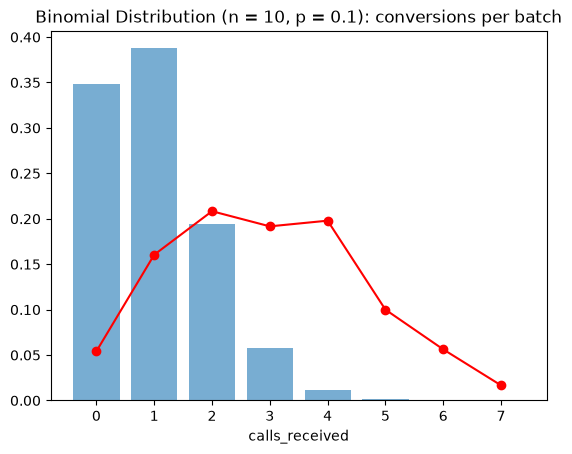

In [30]:
# Plot
ks = range(0, 8)
plt.bar(ks, [stats.binom.pmf(k, n_trials, p) for k in ks], alpha = 0.6, label = 'Theory')
df['calls_received'].value_counts(normalize = True).sort_values().reindex(ks, fill_value = 0).plot(
    kind = 'line', marker = 'o', color = 'red', label = 'observed')
plt.title('Binomial Distribution (n = 10, p = 0.1): conversions per batch')
plt.show()

In [ ]:
#the observed and theoretiocal vaues are not matching because the number of data points are very less n = 10

In [14]:
#poisson distribution


In [16]:
#importing the data
df = pd.read_csv("support_calls.csv")
df.head()

,minute,calls_received
0,1,3
1,2,5
2,3,5
3,4,6
4,5,3


In [17]:
#average rate
lam = df['calls_received'].mean()
print(f'observed average rate (lambda): {lam:.3f}')

observed average rate (lambda): 3.019


In [20]:
lam = 3

In [21]:
# Theory vs observed
print("\nk : theory vs Observed")
obs = df['calls_received'].value_counts(normalize = True).sort_index()
for k in range(0, 8):
    print(f"{k} : {stats.poisson.pmf(k, lam) : .3f} {obs.get(k, 0) : .3f}")


k : theory vs Observed
0 :  0.050  0.054
1 :  0.149  0.160
2 :  0.224  0.208
3 :  0.224  0.192
4 :  0.168  0.198
5 :  0.101  0.100
6 :  0.050  0.056
7 :  0.022  0.017


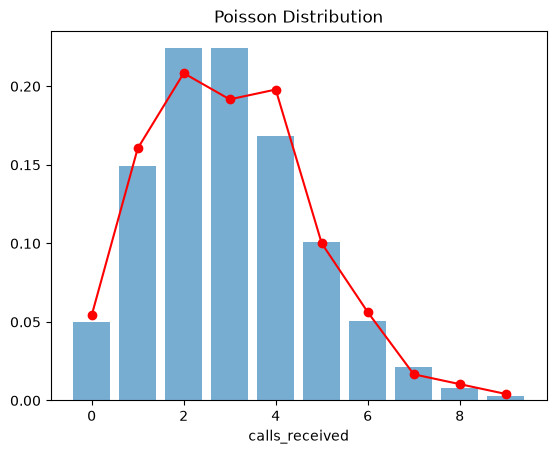

In [22]:
# Plot
ks = range(0, 10)
plt.bar(ks, [stats.poisson.pmf(k, lam) for k in ks], alpha = 0.6, label = 'Theory')
obs.reindex(ks, fill_value = 0).plot(kind = 'line', marker = 'o', color = 'red', label = 'Observed')
plt.title(f'Poisson Distribution')
plt.show()

In [23]:
#the values are almost matching